In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Hyperparameters for the simplified model
img_size = 224  # Input image size
patch_size = 16  # Size of the patches extracted from the image
num_patches = (img_size // patch_size) ** 2  # Number of patches
embedding_dim = 32  # Smaller embedding dimension for fewer trainable parameters
num_heads = 2  # Fewer attention heads
num_transformer_layers = 4  # Fewer transformer layers
mlp_head_units = [256, 128]  # Smaller MLP head units
num_classes = 7  # Number of classes for skin cancer classification
batch_size = 32  # Reduced batch size for faster training

# Step 1: Create the Patch layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Step 2: Patch Encoding Layer
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, embedding_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(embedding_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=embedding_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

# Step 3: Create the Vision Transformer (ViT) Model with fewer trainable parameters
def create_simple_vit_classifier():
    inputs = layers.Input(shape=(img_size, img_size, 3))

    # Create patches
    patches = Patches(patch_size)(inputs)

    # Encode patches
    encoded_patches = PatchEncoder(num_patches, embedding_dim)(patches)

    # Create multiple transformer blocks
    for _ in range(num_transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        # Multi-head attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embedding_dim, dropout=0.1
        )(x1, x1)

        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])

        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x3 = layers.Dense(embedding_dim * 2, activation=tf.nn.gelu)(x3)
        x3 = layers.Dense(embedding_dim, activation=tf.nn.gelu)(x3)

        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])

    # Global average pooling
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)

    # Add MLP head
    x = layers.Dense(mlp_head_units[0], activation=tf.nn.gelu)(representation)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(mlp_head_units[1], activation=tf.nn.gelu)(x)
    x = layers.Dropout(0.5)(x)

    # Final classification layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=inputs, outputs=outputs)

    return model

# Compile the model
simple_vit_model = create_simple_vit_classifier()
simple_vit_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary to check the number of parameters
simple_vit_model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patches (Patches)         │ (None, None, 768)      │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_encoder             │ (None, 196, 32)        │         30,880 │ patches[0][0]          │
│ (PatchEncoder)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 196, 32)        │             64 │ patch_encoder[0][0]    │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 196, 32)        │          8,416 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 196, 32)        │              0 │ multi_head_attention[… │
│                           │                        │                │ patch_encoder[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 196, 32)        │             64 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 196, 64)        │          2,112 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 196, 32)        │          2,080 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 196, 32)        │              0 │ dense_2[0][0],         │
│                           │                        │                │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 196, 32)        │             64 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 196, 32)        │          8,416 │ layer_normalization_2… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 196, 32)        │              0 │ multi_head_attention_… │
│                           │                        │                │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_3     │ (None, 196, 32)        │             64 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)      

 Total params: 124,135 (484.90 KB)

 Trainable params: 124,135 (484.90 KB)

 Non-trainable params: 0 (0.00 B)

Found 38569 files belonging to 7 classes.
Found 938 files belonging to 7 classes.
Epoch 1/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 70s 58ms/step - accuracy: 0.7099 - loss: 0.7559 - val_accuracy: 0.8412 - val_loss: 0.4856
Epoch 2/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 73s 61ms/step - accuracy: 0.7074 - loss: 0.7627 - val_accuracy: 0.8081 - val_loss: 0.5407
Epoch 3/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 70s 58ms/step - accuracy: 0.7090 - loss: 0.7580 - val_accuracy: 0.8230 - val_loss: 0.5223
Epoch 4/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.7115 - loss: 0.7524 - val_accuracy: 0.8241 - val_loss: 0.5322
Epoch 5/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.7124 - loss: 0.7448 - val_accuracy: 0.8028 - val_loss: 0.5411
Epoch 6/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 72s 60ms/step - accuracy: 0.7142 - loss: 0.7424 - val_accuracy: 0.8284 - val_loss: 0.5117
Epoch 7/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.7089 - loss: 0.7532 - val_accuracy: 0.8262 - val_loss: 0

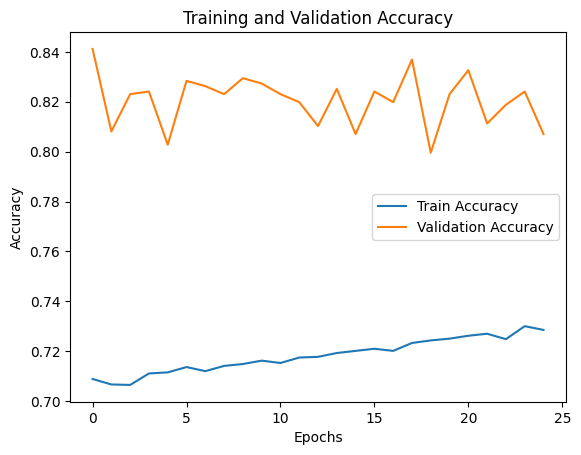

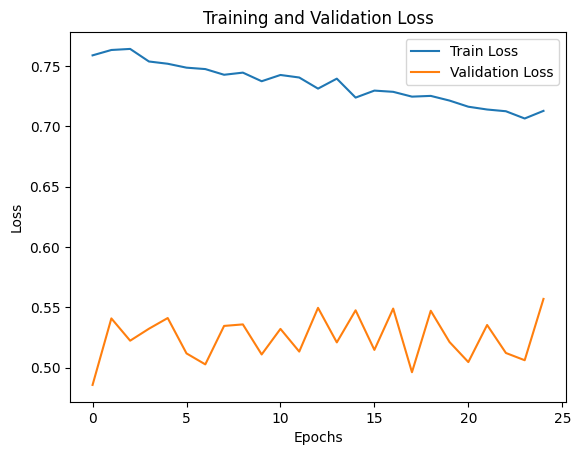

ValueError: Unrecognized data type: x=[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None))>, <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None))>] (of type <class 'list'>)

In [14]:
# Step 4: Load Dataset from Directory
train_dir = '/content/base_dir/train_dir' # Replace with your dataset's directory
val_dir = '/content/base_dir/val_dir'  # Replace with your validation dataset's directory

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    label_mode='categorical'  # Use 'categorical' for multi-class classification
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    label_mode='categorical'
)

# Train the model
history = simple_vit_model.fit(train_dataset, validation_data=val_dataset, epochs=25)

# Evaluate the model
train_loss, train_acc = simple_vit_model.evaluate(train_dataset)
val_loss, val_acc = simple_vit_model.evaluate(val_dataset)

print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# Plot training and validation accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 10: Evaluation Metrics (Confusion Matrix and Classification Report)
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred =  simple_vit_model.predict([val_dataset, val_dataset])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Classification Report
report = classification_report(y_true_classes, y_pred_classes, target_names=val_dataset.class_names)
print("\nClassification Report:\n", report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=val_dataset.class_names, yticklabels=val_dataset.class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


# Step 8: Save the Model
model_save_path = "vit_skin_cancer_classifier.keras"
simple_vit_model.save(model_save_path)

# Step 9: Load the Model
# You can later load the model using the following command:
simple_vit_model = tf.keras.models.load_model(model_save_path)

# Step 10: Download the Model
from google.colab import files
files.download(model_save_path)  # This will download the saved model to your local machine

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.7940 - loss: 0.5733
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step
Validation Accuracy: 60.87%

Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        26
         bcc       0.00      0.00      0.00        30
         bkl       0.06      0.05      0.06        75
          df       0.00      0.00      0.00         6
         mel       0.02      0.03      0.02        39
          nv       0.80      0.75      0.78       751
        vasc       0.00      0.00      0.00        11

    accuracy                           0.61       938
   macro avg       0.13      0.12      0.12       938
weighted avg       0.65      0.61      0.63       938


Confusion Matrix:
 [[  0   4   2   0   0  19   1]
 [  2   0   4   0   3  20   1]
 [  0   6   4   1   2  60   2]
 [  0   0   0   0   0   6   0]
 [  2   2   2   1   1  29   2]
 [ 18  55  50   7  45 566  10]
 [  1   0   1   0   2   7  

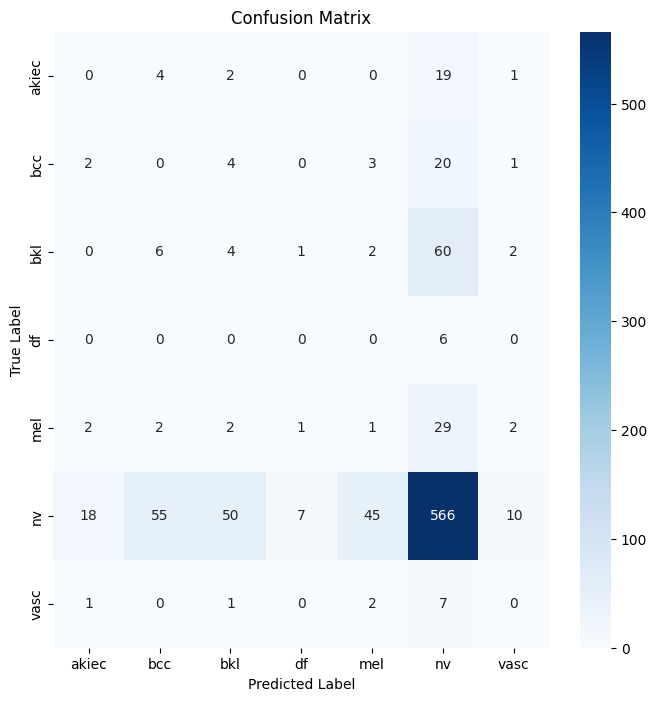

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Evaluate on the validation set and get predictions
val_loss, val_acc = simple_vit_model.evaluate(val_dataset)

# Get the true labels from the validation dataset
y_true = np.concatenate([y for x, y in val_dataset], axis=0)

# Get predictions from the model
y_pred = simple_vit_model.predict(val_dataset)

# Convert predictions from probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Step 2: Print accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Step 3: Print classification report for precision, recall, and f1-score
report = classification_report(y_true_classes, y_pred_classes, target_names=val_dataset.class_names)
print("\nClassification Report:\n", report)

# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:\n", conf_matrix)

# (Optional) Visualizing the confusion matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=val_dataset.class_names, yticklabels=val_dataset.class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [17]:

# Step 8: Save the Model
model_save_path = "vit_skin_cancer_classifier.keras"
simple_vit_model.save(model_save_path)


# Step 10: Download the Model
from google.colab import files
files.download(model_save_path)  # This will download the saved model to your local machine

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from google.colab import files

files.upload() #this will prompt you to upload the kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"malaikahasnatmalik","key":"0875200a145725f6f909b13d8d19a0cf"}'}

In [2]:
!ls -lha kaggle.json

-rw-r--r-- 1 root root 74 Oct  5 17:14 kaggle.json


In [3]:
!pip install -q kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!pwd

/content


In [7]:
!kaggle datasets list

ref                                                            title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
lainguyn123/student-performance-factors                        Student Performance Factors                          94KB  2024-09-02 10:53:57          23524        426  1.0              
abdulszz/spotify-most-streamed-songs                           Spotify Most Streamed Songs                          60KB  2024-09-07 18:23:14           8285        104  1.0              
ayushi10kumari/top-rated-movie-dataset                         Top Rated Movie Dataset                               1MB  2024-09-07 17:38:12           2088         23  0.9411765        
valakhorasani/electric-vehicle-charging-patterns               El

In [8]:
!kaggle datasets download -d utkarshps/skin-cancer-mnist10000-ham-augmented-dataset

Dataset URL: https://www.kaggle.com/datasets/utkarshps/skin-cancer-mnist10000-ham-augmented-dataset
License(s): CC-BY-NC-SA-4.0
 99% 2.75G/2.77G [00:25<00:00, 142MB/s]
100% 2.77G/2.77G [00:25<00:00, 114MB/s]


In [9]:
!unzip skin-cancer-mnist10000-ham-augmented-dataset

Streaming output truncated to the last 5000 lines.
  inflating: base_dir/train_dir/vasc/_124_9541474.jpg  
  inflating: base_dir/train_dir/vasc/_124_9772208.jpg  
  inflating: base_dir/train_dir/vasc/_125_1175166.jpg  
  inflating: base_dir/train_dir/vasc/_125_1449418.jpg  
  inflating: base_dir/train_dir/vasc/_125_2119583.jpg  
  inflating: base_dir/train_dir/vasc/_125_2119666.jpg  
  inflating: base_dir/train_dir/vasc/_125_2164554.jpg  
  inflating: base_dir/train_dir/vasc/_125_2256805.jpg  
  inflating: base_dir/train_dir/vasc/_125_2488751.jpg  
  inflating: base_dir/train_dir/vasc/_125_3149868.jpg  
  inflating: base_dir/train_dir/vasc/_125_331766.jpg  
  inflating: base_dir/train_dir/vasc/_125_3347656.jpg  
  inflating: base_dir/train_dir/vasc/_125_3881906.jpg  
  inflating: base_dir/train_dir/vasc/_125_3983138.jpg  
  inflating: base_dir/train_dir/vasc/_125_4217599.jpg  
  inflating: base_dir/train_dir/vasc/_125_4769564.jpg  
  inflating: base_dir/train_dir/vasc/_125_4771093.jpg 